# Dimensionality Reduction - PCA (Principal Component Analysis)



1. Import required libraries and Load the Dataset

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

In [2]:
from google.colab import files
uploaded = files.upload()


Saving heart_disease_cleaned.csv to heart_disease_cleaned.csv


In [4]:
df = pd.read_csv(r'heart_disease_cleaned.csv')

In [ ]:
df.head()

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,NumMajorVessels,HeartDisease,Thalassemia_6,Thalassemia_7,ChestPainType_2,ChestPainType_3,ChestPainType_4,RestingECG_1,RestingECG_2,ST_Slope_2,ST_Slope_3
0,0.948726,1,0.757525,-0.264900,1,0.017197,0,1.087338,0,0,True,False,False,False,False,False,True,False,True
1,1.392002,1,1.611220,0.760415,0,-1.821905,1,0.397182,3,2,False,False,False,False,True,False,True,True,False
2,1.392002,1,-0.665300,-0.342283,0,-0.902354,1,1.346147,2,1,False,True,False,False,True,False,True,True,False
3,-1.932564,1,-0.096170,0.063974,0,1.637359,0,2.036303,0,0,False,False,False,True,False,False,False,False,True
4,-1.489288,0,-0.096170,-0.825922,0,0.980537,0,0.310912,0,0,False,False,True,False,False,False,True,False,False


In [5]:
df.tail()

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,NumMajorVessels,HeartDisease,Thalassemia_6,Thalassemia_7,ChestPainType_2,ChestPainType_3,ChestPainType_4,RestingECG_1,RestingECG_2,ST_Slope_2,ST_Slope_3
298,-1.046013,1,-1.234430,0.334813,0,-0.770990,0,0.138373,0,1,False,True,False,False,False,False,False,True,False
299,1.502821,1,0.700612,-1.038723,1,-0.376896,0,2.036303,2,2,False,True,False,False,True,False,False,True,False
300,0.283813,1,-0.096170,-1.383268,0,-1.515388,1,0.138373,1,3,False,True,False,False,True,False,False,True,False
301,0.283813,0,-0.096170,-0.206864,0,1.068113,0,-0.896862,1,1,False,False,True,False,False,False,True,True,False
302,-1.821745,1,0.359134,-1.383268,0,1.024325,0,-0.896862,0,0,False,False,False,True,False,False,False,False,False


2. Separate features and target

In [6]:
X = df.drop("HeartDisease", axis=1)  # features
y = df["HeartDisease"]               # target


3. Standardize features

In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

4. Apply PCA

In [8]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

5. Explained variance ratio

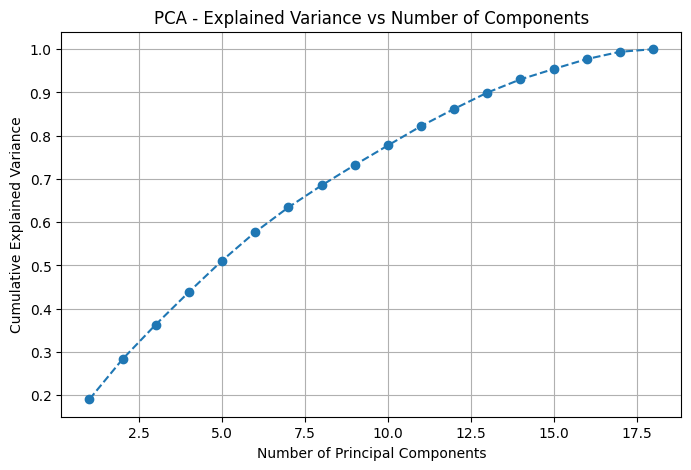

In [9]:
explained_variance = pca.explained_variance_ratio_

# Cumulative explained variance
cumulative_variance = np.cumsum(explained_variance)

# Plot cumulative variance
plt.figure(figsize=(8,5))
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o', linestyle='--')
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA - Explained Variance vs Number of Components")
plt.grid(True)
plt.show()


6. Scatter plot for first 2 principal components

In [10]:
n_components = np.argmax(cumulative_variance >= 0.95) + 1
print("Optimal number of components (>=95% variance):", n_components)

Optimal number of components (>=95% variance): 15


In [11]:
pca_final = PCA(n_components=n_components)
X_pca_final = pca_final.fit_transform(X_scaled)

In [12]:
pca_cols = [f'PC{i+1}' for i in range(n_components)]
X_pca_df = pd.DataFrame(X_pca_final, columns=pca_cols)
X_pca_df['HeartDisease'] = y.values

In [14]:
X_pca_df.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,HeartDisease
0,0.684512,2.262340,4.306566,-2.011936,2.767598,1.395920,1.132984,-0.243817,-0.012057,0.051557,0.567220,0.723671,0.174570,-1.469093,0.386863,0
1,3.570333,1.260364,-1.304185,-0.681895,0.017665,0.769020,-0.003374,-0.248998,-0.204954,-0.287651,-0.771801,0.444649,-0.340249,1.460697,-0.856000,2
2,3.402447,-0.713093,-0.319453,0.114736,-0.740147,0.289340,-0.301261,-0.657590,-1.090397,-0.279065,0.148344,-0.406428,-0.313430,0.604914,-0.251198,1
3,-1.651317,0.220787,3.832794,0.045060,0.317091,-2.585866,0.762376,-1.167258,-0.740746,0.517406,0.203725,0.964626,1.884434,0.072456,-0.828009,0
4,-2.501824,-0.457629,-0.488898,-0.981663,1.199871,-0.148467,0.378493,-1.418217,0.087860,-0.164612,0.696152,-1.421694,0.631125,0.917852,0.302566,0


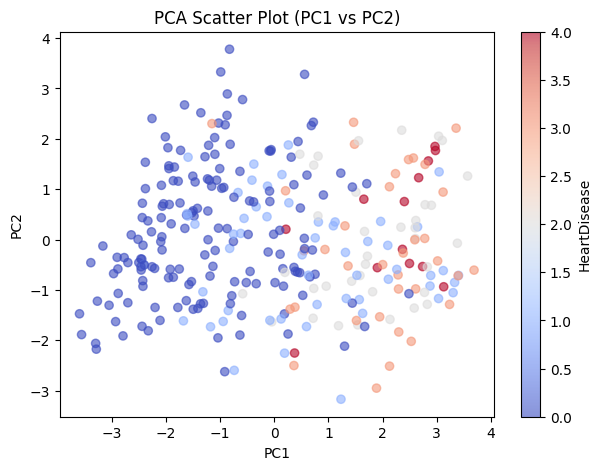

In [15]:
plt.figure(figsize=(7,5))
plt.scatter(X_pca_df['PC1'], X_pca_df['PC2'], c=y, cmap='coolwarm', alpha=0.6)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Scatter Plot (PC1 vs PC2)")
plt.colorbar(label="HeartDisease")
plt.show()

In [16]:
pca_cols = [f'PC{i+1}' for i in range(n_components)]
X_pca_df = pd.DataFrame(X_pca_final, columns=pca_cols)
X_pca_df['HeartDisease'] = y.values

In [19]:
X_pca_df.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,HeartDisease
0,0.684512,2.262340,4.306566,-2.011936,2.767598,1.395920,1.132984,-0.243817,-0.012057,0.051557,0.567220,0.723671,0.174570,-1.469093,0.386863,0
1,3.570333,1.260364,-1.304185,-0.681895,0.017665,0.769020,-0.003374,-0.248998,-0.204954,-0.287651,-0.771801,0.444649,-0.340249,1.460697,-0.856000,2
2,3.402447,-0.713093,-0.319453,0.114736,-0.740147,0.289340,-0.301261,-0.657590,-1.090397,-0.279065,0.148344,-0.406428,-0.313430,0.604914,-0.251198,1
3,-1.651317,0.220787,3.832794,0.045060,0.317091,-2.585866,0.762376,-1.167258,-0.740746,0.517406,0.203725,0.964626,1.884434,0.072456,-0.828009,0
4,-2.501824,-0.457629,-0.488898,-0.981663,1.199871,-0.148467,0.378493,-1.418217,0.087860,-0.164612,0.696152,-1.421694,0.631125,0.917852,0.302566,0


# -> End of This File -> 03_feature_selection.ipynb